In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from dotenv import load_dotenv

# ML Libraries
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (mean_squared_error, mean_absolute_error, 
                              r2_score, mean_absolute_percentage_error)
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, Lasso
import xgboost as xgb
import lightgbm as lgb
import shap

load_dotenv()
plt.style.use('seaborn-v0_8-whitegrid')

# Load master dataset
PROCESSED_DIR = Path("../data/processed")
MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(PROCESSED_DIR / "master_dataset.csv")

print(f"✅ Master dataset loaded: {df.shape}")
print(f"   Target: produktivitas_ton_per_ha")
print(f"   Range target: {df['produktivitas_ton_per_ha'].min():.2f} – {df['produktivitas_ton_per_ha'].max():.2f} ton/ha")

python-dotenv could not parse statement starting at line 1


✅ Master dataset loaded: (1624, 51)
   Target: produktivitas_ton_per_ha
   Range target: 4.56 – 7.03 ton/ha


In [2]:
# Definisi feature columns
FEATURE_COLS = [
    # Iklim & Cuaca
    'enso_mean', 'enso_lag1_mean', 'enso_lag3_mean', 'bulan_el_nino', 'bulan_la_nina',
    'curah_hujan_total', 'curah_hujan_mean', 'curah_hujan_std', 'curah_hujan_max',
    'hari_hujan_total', 'suhu_mean', 'suhu_max', 'kelembaban_mean',
    'anomali_curah_hujan', 'pct_anomali_hujan',
    # Satelit NDVI
    'ndvi_mean', 'ndvi_max', 'ndvi_std', 'pct_lahan_sangat_baik', 'pct_lahan_buruk',
    # Irigasi & Infrastruktur
    'skor_irigasi', 'jumlah_pompa_unit', 'kapasitas_pompa_per_ha',
    'indeks_pertanaman', 'persen_irigasi_kondisi_baik', 'era_pompanisasi',
    # Ekonomi
    'harga_mean', 'harga_lag1', 'harga_volatility', 'harga_yoy_change',
    'rasio_gabah_beras', 'impor_volume', 'harga_impor_idr',
    # Lahan
    'luas_panen_ha',
    # Encoding
    'musim_tanam_enc', 'provinsi_enc'
]

TARGET = 'produktivitas_ton_per_ha'

# Filter kolom yang ada
available_features = [c for c in FEATURE_COLS if c in df.columns]
print(f"✅ Features yang digunakan: {len(available_features)}")

X = df[available_features].copy()
y = df[TARGET].copy()

# Train-test split (80-20, stratified by tahun)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling untuk model linear
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✅ Train set: {X_train.shape}")
print(f"✅ Test set : {X_test.shape}")
print(f"✅ Target distribusi:")
print(f"   Mean : {y_train.mean():.3f} ton/ha")
print(f"   Std  : {y_train.std():.3f} ton/ha")
print(f"   Min  : {y_train.min():.3f} ton/ha")
print(f"   Max  : {y_train.max():.3f} ton/ha")

✅ Features yang digunakan: 36
✅ Train set: (1299, 36)
✅ Test set : (325, 36)
✅ Target distribusi:
   Mean : 5.632 ton/ha
   Std  : 0.460 ton/ha
   Min  : 4.564 ton/ha
   Max  : 7.025 ton/ha


In [3]:
print("🤖 Training Baseline Models...")
print("=" * 60)

# Fungsi evaluasi
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, scaled=False):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    mae  = mean_absolute_error(y_te, y_pred)
    r2   = r2_score(y_te, y_pred)
    mape = mean_absolute_percentage_error(y_te, y_pred) * 100
    
    # Cross validation
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_tr, y_tr, cv=cv, 
                                 scoring='neg_root_mean_squared_error')
    cv_rmse = -cv_scores.mean()
    
    print(f"\n📊 {name}")
    print(f"   RMSE  : {rmse:.4f} ton/ha")
    print(f"   MAE   : {mae:.4f} ton/ha")
    print(f"   R²    : {r2:.4f}")
    print(f"   MAPE  : {mape:.2f}%")
    print(f"   CV RMSE (5-fold): {cv_rmse:.4f} ± {(-cv_scores).std():.4f}")
    
    return {
        'model': name, 'rmse': rmse, 'mae': mae, 
        'r2': r2, 'mape': mape, 'cv_rmse': cv_rmse,
        'y_pred': y_pred
    }

results = []

# 1. Ridge Regression (baseline linear)
ridge = Ridge(alpha=1.0)
r = evaluate_model("Ridge Regression", ridge, 
                    X_train_scaled, y_train, X_test_scaled, y_test, scaled=True)
results.append(r)

# 2. Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
r = evaluate_model("Random Forest", rf, X_train, y_train, X_test, y_test)
results.append(r)

# 3. Gradient Boosting
gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
r = evaluate_model("Gradient Boosting", gb, X_train, y_train, X_test, y_test)
results.append(r)

# 4. XGBoost
xgb_model = xgb.XGBRegressor(
    n_estimators=200, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, verbosity=0
)
r = evaluate_model("XGBoost", xgb_model, X_train, y_train, X_test, y_test)
results.append(r)

# 5. LightGBM
lgb_model = lgb.LGBMRegressor(
    n_estimators=200, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, verbose=-1
)
r = evaluate_model("LightGBM", lgb_model, X_train, y_train, X_test, y_test)
results.append(r)

print("\n" + "=" * 60)
print("🏆 RANGKUMAN SEMUA MODEL")
print("=" * 60)
df_results = pd.DataFrame([{k: v for k, v in r.items() if k != 'y_pred'} for r in results])
print(df_results.to_string(index=False))

🤖 Training Baseline Models...

📊 Ridge Regression
   RMSE  : 0.1545 ton/ha
   MAE   : 0.1235 ton/ha
   R²    : 0.8910
   MAPE  : 2.20%
   CV RMSE (5-fold): 0.1514 ± 0.0072

📊 Random Forest
   RMSE  : 0.1625 ton/ha
   MAE   : 0.1290 ton/ha
   R²    : 0.8793
   MAPE  : 2.31%
   CV RMSE (5-fold): 0.1660 ± 0.0060

📊 Gradient Boosting
   RMSE  : 0.1598 ton/ha
   MAE   : 0.1274 ton/ha
   R²    : 0.8834
   MAPE  : 2.28%
   CV RMSE (5-fold): 0.1571 ± 0.0056

📊 XGBoost
   RMSE  : 0.1633 ton/ha
   MAE   : 0.1315 ton/ha
   R²    : 0.8781
   MAPE  : 2.35%
   CV RMSE (5-fold): 0.1656 ± 0.0057

📊 LightGBM
   RMSE  : 0.1608 ton/ha
   MAE   : 0.1301 ton/ha
   R²    : 0.8818
   MAPE  : 2.33%
   CV RMSE (5-fold): 0.1621 ± 0.0064

🏆 RANGKUMAN SEMUA MODEL
            model     rmse      mae       r2     mape  cv_rmse
 Ridge Regression 0.154453 0.123501 0.890978 2.200562 0.151358
    Random Forest 0.162525 0.129023 0.879286 2.313578 0.166001
Gradient Boosting 0.159754 0.127379 0.883366 2.276195 0.157140
  

In [4]:
from sklearn.model_selection import RandomizedSearchCV

print("🔧 Hyperparameter Tuning XGBoost...")

param_dist = {
    'n_estimators': [200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [4, 6, 8],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.2],
    'reg_alpha': [0, 0.1, 0.5],
    'reg_lambda': [1, 1.5, 2]
}

xgb_base = xgb.XGBRegressor(random_state=42, n_jobs=-1, verbosity=0)
cv = KFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    xgb_base, param_distributions=param_dist,
    n_iter=30, cv=cv,
    scoring='neg_root_mean_squared_error',
    random_state=42, n_jobs=-1, verbose=1
)

random_search.fit(X_train, y_train)

print(f"\n✅ Best params: {random_search.best_params_}")
print(f"✅ Best CV RMSE: {-random_search.best_score_:.4f}")

# Train model terbaik
best_xgb = random_search.best_estimator_
y_pred_best = best_xgb.predict(X_test)

rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
mae_best  = mean_absolute_error(y_test, y_pred_best)
r2_best   = r2_score(y_test, y_pred_best)
mape_best = mean_absolute_percentage_error(y_test, y_pred_best) * 100

print(f"\n🏆 BEST XGBoost Performance:")
print(f"   RMSE : {rmse_best:.4f} ton/ha")
print(f"   MAE  : {mae_best:.4f} ton/ha")
print(f"   R²   : {r2_best:.4f}")
print(f"   MAPE : {mape_best:.2f}%")

🔧 Hyperparameter Tuning XGBoost...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

✅ Best params: {'subsample': 0.9, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.9}
✅ Best CV RMSE: 0.1575

🏆 BEST XGBoost Performance:
   RMSE : 0.1577 ton/ha
   MAE  : 0.1259 ton/ha
   R²   : 0.8863
   MAPE : 2.25%


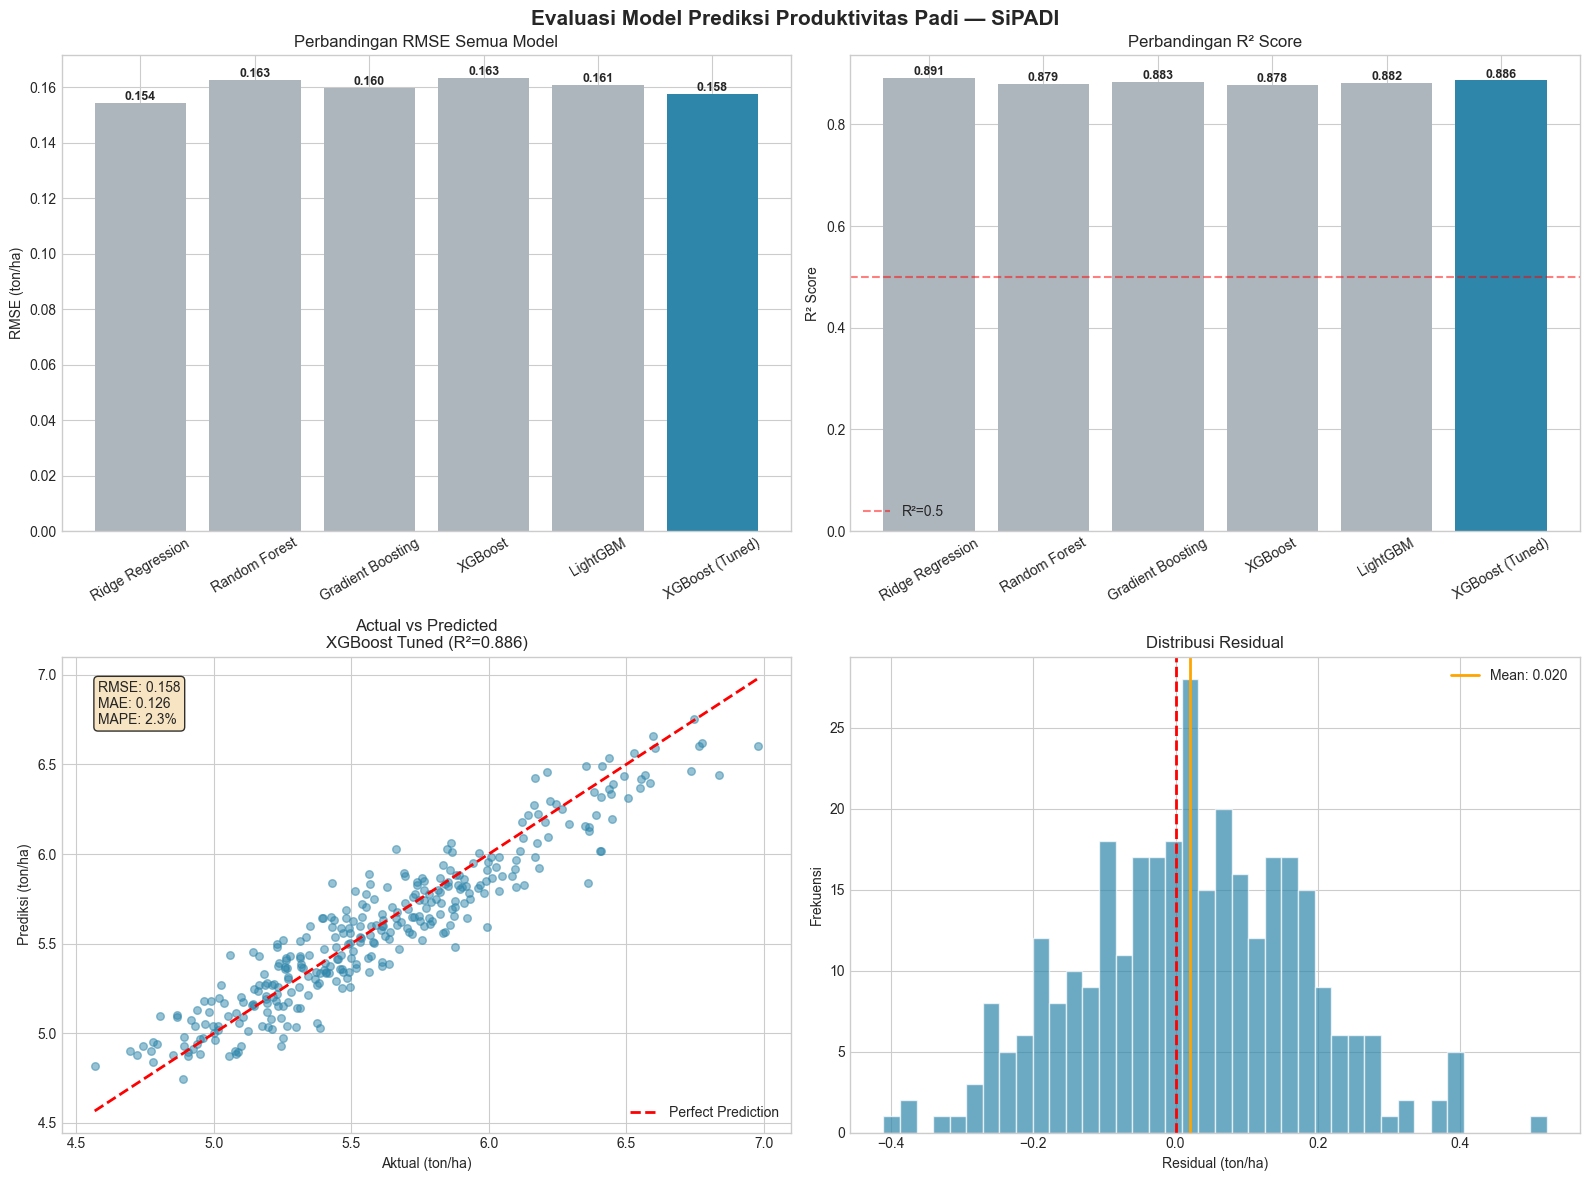

✅ Plot evaluasi tersimpan!


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Evaluasi Model Prediksi Produktivitas Padi — SiPADI', 
             fontsize=15, fontweight='bold')

# Plot 1: Model comparison RMSE
ax = axes[0, 0]
model_names = [r['model'] for r in results] + ['XGBoost (Tuned)']
rmse_values = [r['rmse'] for r in results] + [rmse_best]
colors = ['#adb5bd'] * len(results) + ['#2E86AB']
bars = ax.bar(model_names, rmse_values, color=colors)
ax.set_ylabel('RMSE (ton/ha)')
ax.set_title('Perbandingan RMSE Semua Model')
ax.tick_params(axis='x', rotation=30)
for bar, val in zip(bars, rmse_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

# Plot 2: R² comparison
ax = axes[0, 1]
r2_values = [r['r2'] for r in results] + [r2_best]
bars = ax.bar(model_names, r2_values, color=colors)
ax.set_ylabel('R² Score')
ax.set_title('Perbandingan R² Score')
ax.tick_params(axis='x', rotation=30)
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='R²=0.5')
ax.legend()
for bar, val in zip(bars, r2_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

# Plot 3: Actual vs Predicted (best model)
ax = axes[1, 0]
ax.scatter(y_test, y_pred_best, alpha=0.5, color='#2E86AB', s=30)
min_val = min(y_test.min(), y_pred_best.min())
max_val = max(y_test.max(), y_pred_best.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
ax.set_xlabel('Aktual (ton/ha)')
ax.set_ylabel('Prediksi (ton/ha)')
ax.set_title(f'Actual vs Predicted\nXGBoost Tuned (R²={r2_best:.3f})')
ax.legend()
ax.text(0.05, 0.95, f'RMSE: {rmse_best:.3f}\nMAE: {mae_best:.3f}\nMAPE: {mape_best:.1f}%',
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Plot 4: Residual distribution
ax = axes[1, 1]
residuals = y_test - y_pred_best
ax.hist(residuals, bins=40, color='#2E86AB', alpha=0.7, edgecolor='white')
ax.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax.axvline(x=residuals.mean(), color='orange', linestyle='-', 
           linewidth=2, label=f'Mean: {residuals.mean():.3f}')
ax.set_xlabel('Residual (ton/ha)')
ax.set_ylabel('Frekuensi')
ax.set_title('Distribusi Residual')
ax.legend()

plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'model_regression_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot evaluasi tersimpan!")

🔍 SHAP Feature Importance Analysis...


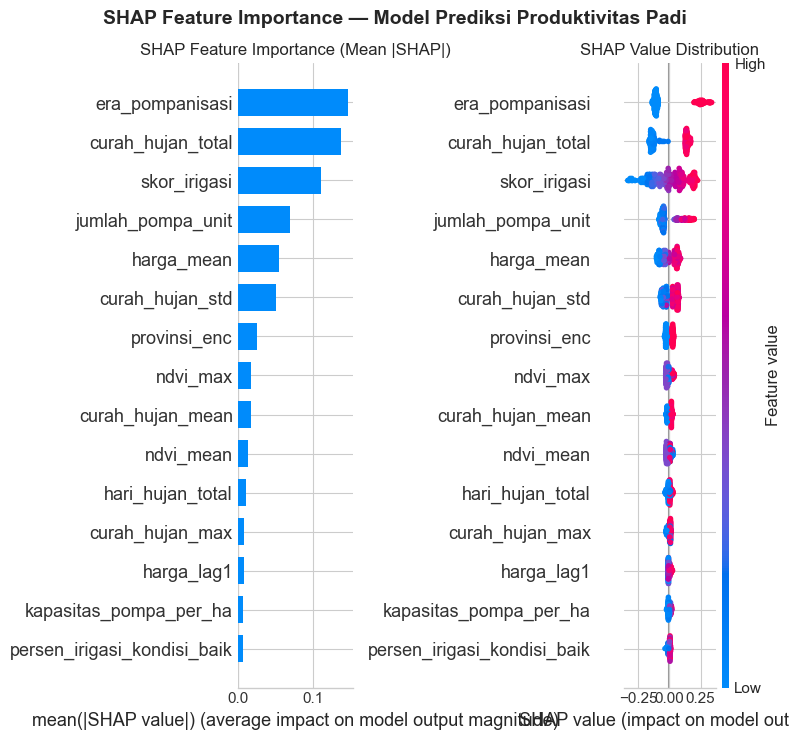

✅ SHAP plot tersimpan!


In [6]:
print("🔍 SHAP Feature Importance Analysis...")

explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('SHAP Feature Importance — Model Prediksi Produktivitas Padi',
             fontsize=14, fontweight='bold')

# Plot 1: SHAP bar plot
plt.sca(axes[0])
shap.summary_plot(shap_values, X_test, plot_type='bar',
                  feature_names=available_features,
                  show=False, max_display=15)
axes[0].set_title('SHAP Feature Importance (Mean |SHAP|)')

# Plot 2: SHAP beeswarm
plt.sca(axes[1])
shap.summary_plot(shap_values, X_test,
                  feature_names=available_features,
                  show=False, max_display=15)
axes[1].set_title('SHAP Value Distribution')

plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'shap_regression.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ SHAP plot tersimpan!")

In [7]:
from azure.storage.blob import BlobServiceClient

print("💾 Menyimpan model...")

# Simpan model lokal
joblib.dump(best_xgb, MODELS_DIR / 'productivity_model.pkl')
joblib.dump(scaler, MODELS_DIR / 'scaler.pkl')
joblib.dump(available_features, MODELS_DIR / 'feature_cols.pkl')

print("✅ Model tersimpan lokal!")

# Upload ke Azure Blob Storage
blob_service = BlobServiceClient.from_connection_string(
    os.getenv("AZURE_STORAGE_CONNECTION_STRING")
)

model_files = [
    (MODELS_DIR / 'productivity_model.pkl', 'models/productivity_model.pkl'),
    (MODELS_DIR / 'scaler.pkl', 'models/scaler.pkl'),
    (MODELS_DIR / 'feature_cols.pkl', 'models/feature_cols.pkl'),
]

for local_path, blob_name in model_files:
    blob_client = blob_service.get_blob_client(
        container="sipadi-models", blob=blob_name
    )
    with open(local_path, "rb") as f:
        blob_client.upload_blob(f, overwrite=True)
    print(f"☁️  Uploaded: {blob_name}")

# Ringkasan final
print("\n" + "=" * 60)
print("🏆 FINAL MODEL SUMMARY — REGRESSION")
print("=" * 60)
print(f"   Model    : XGBoost Regressor (Tuned)")
print(f"   Features : {len(available_features)}")
print(f"   RMSE     : {rmse_best:.4f} ton/ha")
print(f"   MAE      : {mae_best:.4f} ton/ha")
print(f"   R²       : {r2_best:.4f}")
print(f"   MAPE     : {mape_best:.2f}%")
print(f"   Storage  : Azure Blob (sipadi-models)")
print("=" * 60)

💾 Menyimpan model...
✅ Model tersimpan lokal!
☁️  Uploaded: models/productivity_model.pkl
☁️  Uploaded: models/scaler.pkl
☁️  Uploaded: models/feature_cols.pkl

🏆 FINAL MODEL SUMMARY — REGRESSION
   Model    : XGBoost Regressor (Tuned)
   Features : 36
   RMSE     : 0.1577 ton/ha
   MAE      : 0.1259 ton/ha
   R²       : 0.8863
   MAPE     : 2.25%
   Storage  : Azure Blob (sipadi-models)


In [8]:
from pathlib import Path
import pandas as pd
import numpy as np

RAW_DIR = Path("../data/raw")
PROCESSED_DIR = Path("../data/processed")

# Cek data produksi terbaru
df_check = pd.read_csv(RAW_DIR / "produksi_padi.csv")
print("Produktivitas stats TERBARU:")
print(df_check['produktivitas_ton_per_ha'].describe())
print(f"\nStd: {df_check['produktivitas_ton_per_ha'].std():.4f}")

# Cek master dataset
df_master_check = pd.read_csv(PROCESSED_DIR / "master_dataset.csv")
print(f"\nMaster dataset shape: {df_master_check.shape}")
print("Target stats:")
print(df_master_check['produktivitas_ton_per_ha'].describe())

Produktivitas stats TERBARU:
count    1624.000000
mean        5.624899
std         0.461595
min         4.564000
25%         5.273750
50%         5.607500
75%         5.920000
max         7.025000
Name: produktivitas_ton_per_ha, dtype: float64

Std: 0.4616

Master dataset shape: (1624, 51)
Target stats:
count    1624.000000
mean        5.624899
std         0.461595
min         4.564000
25%         5.273750
50%         5.607500
75%         5.920000
max         7.025000
Name: produktivitas_ton_per_ha, dtype: float64
